# Mosaic Tutorial

The goal of this notebook is to explain and show the process of making a mosaic image. Mosaics is a method that enables an individual to stitch images together to create one image capable of showing an object that is much larger than the field of view of a telescope. 

Mosaics can be used for:
- Creating color images of large objects
- Conduct a complete analysis of large clusters. (i.e. color magnitude diagrams, photometry)

## Imports

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval
from pathlib import Path
import os
import warnings
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import traceback
import tkinter as tk
from tkinter import filedialog

## Loading in the Data and Displaying

In [2]:
# Interactive widget to select a folder containing FITS images
root = tk.Tk()
root.withdraw()

folder = filedialog.askdirectory(
    title="Select folder containing FITS images"
)

root.destroy()


folder = Path(folder)
print(f"Selected folder: {folder}")

Selected folder: /home/pendragon/Downloads/2026-04-11/Reduced


In [3]:
fits_files = sorted(
    file for file in folder.rglob("*")
    if file.suffix.lower() in {".fits", ".fit", ".fts"}
)

print(f"Found {len(fits_files)} FITS files.")

Found 35 FITS files.


In [4]:
image_groups = {}

for file in fits_files:
    
    with fits.open(file) as hdul:
        data = hdul[0].data
        header = hdul[0].header
    
    object_name = str(header.get("OBJECT", "Unknown")).strip()
    filter_name = str(header.get("FILTER", "Unknown")).strip()
    
    if object_name not in image_groups:
        image_groups[object_name] = {}
    
    if filter_name not in image_groups[object_name]:
        image_groups[object_name][filter_name] = []
    
    image_groups[object_name][filter_name].append(data)

In [ ]:
# Displays current structure of the image_groups dictionary
image_groups

{'M101_Q1': {'G': [array([[ 940.28692156,  940.28692156,  940.28692156, ...,  940.28692156,
            940.28692156,  940.28692156],
          [ 940.28692156,  940.28692156,  940.28692156, ...,  940.28692156,
            940.28692156,  940.28692156],
          [ 943.16596209,  942.69904797,  943.58978387, ...,  940.2595037 ,
            941.23628811,  941.94030326],
          ...,
          [ 901.78809355,  914.04511468,  896.80782131, ...,  866.03739687,
           1007.56433228,  997.15098732],
          [ 959.46894288,  908.81506591, 1060.00163872, ...,  980.99724927,
            975.32261275, 1004.27211019],
          [ 866.28333414, 1039.30152861,  991.81660884, ..., 1025.86520218,
           1064.69486627, 1067.78958904]], dtype='>f8'),
   array([[ 751.00760293,  757.58904003,  755.0155615 , ..., 1073.51768095,
           1086.49141779,  882.19242651],
          [ 743.3405598 ,  650.49852095,  703.86878085, ..., 1047.32067203,
            894.2000161 ,  887.46233787],
          

In [ ]:
images = {}
# Code to display the number of images for each object and filter, and sum the images for each filter
# If a user wants to create a mosaic for time series analysis, they will need to avoid summing the images and create individual mosaics for each data point.
for object_name, filters in image_groups.items():
    
    images[object_name] = {}
    
    print(object_name)
    
    for filter_name, data in filters.items():
        
        print(f"    {filter_name}: {len(data)} images")
        
        images[object_name][filter_name] = np.sum(data, axis = 0)

M101_Q1
    G: 3 images
    R: 3 images
    I: 3 images
M101_Q2
    G: 2 images
    R: 3 images
    I: 1 images
M101_Q3
    G: 4 images
    R: 4 images
    I: 3 images
M101_Q4
    G: 3 images
    R: 3 images
    I: 3 images


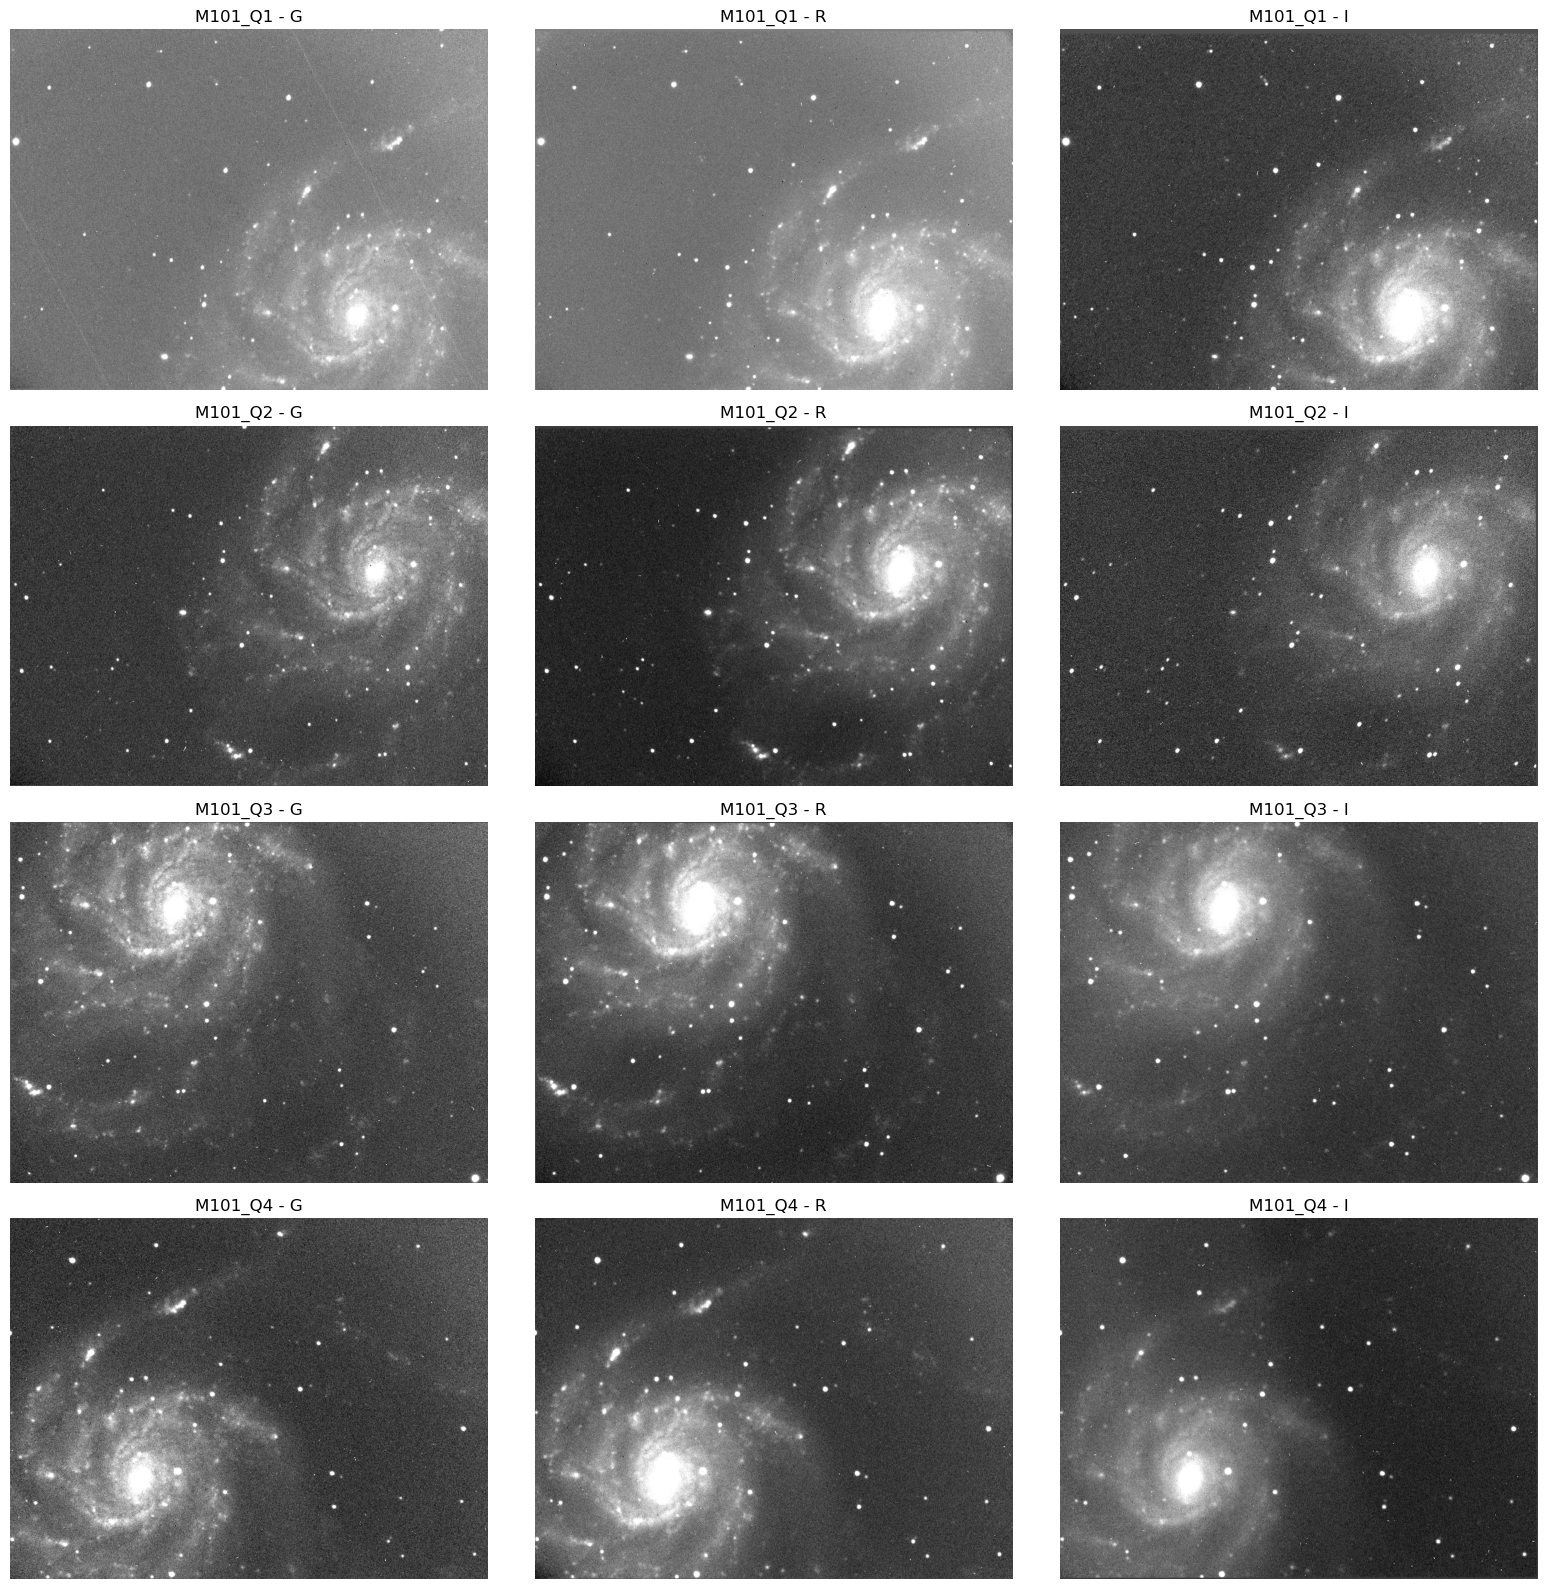

In [ ]:
#Code to display the images of each object 
ncols = 3
nrows = len(images)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4 * nrows)
)

axes = np.asarray(axes).reshape(nrows, ncols)
for row, (object_name, filters) in enumerate(images.items()):

    for col, (filter_name, data) in enumerate(filters.items()):
        axes[row, col].imshow(
            data,
            origin="lower",
            cmap="gray",
            norm=ImageNormalize(data, interval=ZScaleInterval())
        )

        axes[row, col].set_title(
            f"{object_name} - {filter_name}"
        )

        axes[row, col].set_axis_off()

plt.tight_layout()
plt.show()